# Example 17: Satellite-to-Satellite Angles-Only Orbit Determination

A minimal, fully agent-based orbit-determination scenario, and a template for building your
own. Two `Spacecraft` share the lunar environment. An **observer** measures only the
**bearing** (unit line-of-sight direction) to a **target** whose ephemeris is treated as
**known**, and an EKF on the observer estimates the observer's *own* 6-state orbit
$[\mathbf r,\mathbf v]$ (no clock — angles are clock-independent).

Measuring only a *direction* to a *known* landmark is a well-posed, observable navigation
problem (the observer's dynamics tie successive bearings together, and out-of-plane geometry
lets the line of sight sweep for triangulation). Estimating an *unknown* target's **range**
from bearings alone is the classic ill-posed angles-only problem — deliberately not attempted
here.

**What this example demonstrates about the framework** — it is built from the same pieces as
every other scenario, with only two new C++ classes:

* a new observable, `SatBearingMeasurement` (a `MeasurementClone` returning the unit
  line-of-sight, with an autodiff Jacobian), and
* a new estimator application, `AnglesOdtsApp` (`REGISTER_FACTORY_CLASS(Application, ...)`),

both driven from a plain YAML config through `pnt.Simulation`. No new agent or dynamics is
needed — the observer and target reuse the existing self-propagating `Spacecraft`, and both
inherit their truth force model from the shared `world:` block. See the *How to Create a New
Simulation* page for the authoring recipe this example follows.

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Import THIS repo's pylupnt regardless of a global PYTHONPATH, and pin LUPNT_DATA_PATH.
for _base in [Path.cwd(), *Path.cwd().parents]:
    if (_base / "python" / "pylupnt" / "__init__.py").exists():
        sys.path.insert(0, str((_base / "python").resolve()))
        if (_base / "data" / "LuPNT_data").is_dir():
            os.environ["LUPNT_DATA_PATH"] = str((_base / "data" / "LuPNT_data").resolve())
        break

import yaml
import pylupnt as pnt

print(f"pylupnt loaded from: {pnt.__file__}")

[00.00][PyLuPNT] Initializing


pylupnt loaded from: /Users/keidaiiiyama/Documents/sw_navlab/LuPNT/python/pylupnt/__init__.py


## 1. Load the scenario and run

The scenario is `configs/sat_bearing_odts.yaml`: a `world:` force model plus a `target` and an
`observer` `Spacecraft`, the observer hosting `AnglesOdtsApp`. It runs `monte_carlo_runs = 10`
independent trials (same truth + geometry, different measurement-noise / initial-estimate
realizations) so we can look at the *ensemble* convergence, not just one lucky draw.

In [2]:
cfg_path = next(p / "configs" / "sat_bearing_odts.yaml"
                for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "configs" / "sat_bearing_odts.yaml").exists())
cfg = yaml.safe_load(open(cfg_path))

sim = pnt.Simulation(cfg)
sim.run()
app = sim.get_agent("observer").get_application()

t_hr = np.asarray(app.time_grid()) / 3600.0
truth = np.asarray(app.truth_state())          # [N, 6] observer truth [r, v]
est = np.asarray(app.est_state())              # [N, 6] estimate (MC run 0)
sig = np.asarray(app.sigma_state())            # [N, 6] 1-sigma (MC run 0)
pos_rms = np.asarray(app.position_error_rms())  # [N] over the MC ensemble

print(f"Monte-Carlo runs:          {app.monte_carlo_runs()}")
print(f"Final position error (RMS over MC): {app.final_position_error_m():8.2f} m")
print(f"Arc  position error (RMS over MC):  {app.rms_position_error_m():8.2f} m")

Monte-Carlo runs:          10
Final position error (RMS over MC):    29.91 m
Arc  position error (RMS over MC):     33.82 m
[01.76][/Users/keidaiiiyama/Documents/sw_navlab/LuPNT/data/LuPNT_data/output/sat_bearing_odts/sat_bearing_odts.h5] Output file: {}
[01.76][Simulation] Output file: /Users/keidaiiiyama/Documents/sw_navlab/LuPNT/data/LuPNT_data/output/sat_bearing_odts/sat_bearing_odts.h5

[01.97][Simulation] 100%|█��████████| 100/100 [00:01<00:00, 50.5 it/s]


## 2. Convergence

**Left:** the ensemble position-error RMS (over all Monte-Carlo trials) vs. time — the arc
starts at the ~300 m a-priori and pulls down to the tens-of-meters level as the geometry
accumulates. **Right:** the per-axis position error for one representative trial with the
filter's own $3\sigma$ envelope, showing the estimate stays inside its covariance
(consistent).

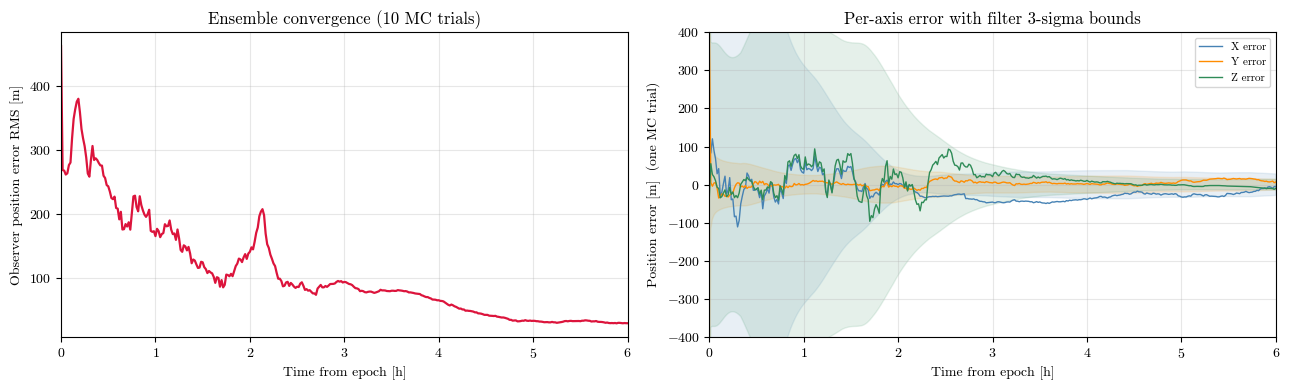

In [3]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4))

ax0.plot(t_hr, pos_rms, color="crimson", lw=1.6)
ax0.set_xlabel("Time from epoch [h]")
ax0.set_ylabel("Observer position error RMS [m]")
ax0.set_title(f"Ensemble convergence ({app.monte_carlo_runs()} MC trials)")
ax0.set_xlim(0, t_hr[-1])
ax0.grid(True, alpha=0.3)

err = est - truth
labels = ["X", "Y", "Z"]
colors = ["steelblue", "darkorange", "seagreen"]
for k in range(3):
    ax1.plot(t_hr, err[:, k], color=colors[k], lw=1.0, label=f"{labels[k]} error")
    ax1.fill_between(t_hr, -3 * sig[:, k], 3 * sig[:, k], color=colors[k], alpha=0.12)
ax1.set_xlabel("Time from epoch [h]")
ax1.set_ylabel("Position error [m]  (one MC trial)")
ax1.set_title("Per-axis error with filter 3-sigma bounds")
ax1.set_xlim(0, t_hr[-1])
ax1.set_ylim(-400, 400)
ax1.legend(fontsize=8, loc="upper right")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Observer orbit

The observer's true trajectory over the arc (Moon-centered inertial, X–Y projection), colored
by the along-track error magnitude of the estimate — the recovered orbit tracks truth to the
tens-of-meters level.

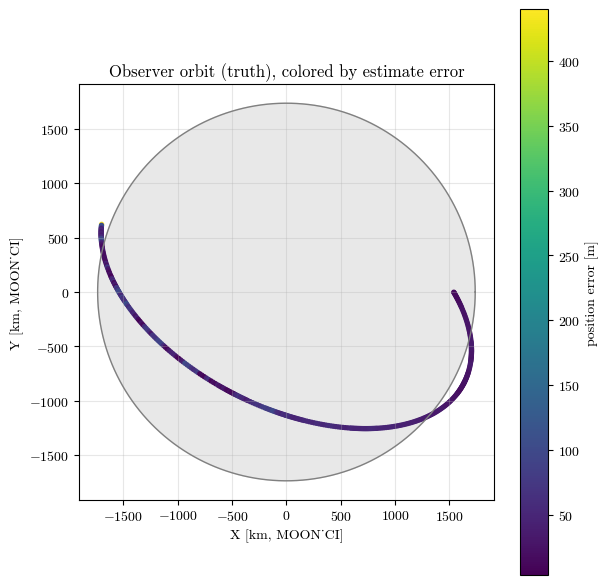

In [4]:
fig, ax = plt.subplots(figsize=(6.2, 6))
R_MOON_KM = 1737.4
theta = np.linspace(0, 2 * np.pi, 200)
ax.plot(R_MOON_KM * np.cos(theta), R_MOON_KM * np.sin(theta), color="gray", lw=1.0)
ax.fill(R_MOON_KM * np.cos(theta), R_MOON_KM * np.sin(theta), color="lightgray", alpha=0.5)
err_norm = np.linalg.norm(est[:, :3] - truth[:, :3], axis=1)
sc = ax.scatter(truth[:, 0] / 1e3, truth[:, 1] / 1e3, c=err_norm, cmap="viridis", s=8)
ax.set_aspect("equal")
ax.set_xlabel("X [km, MOON_CI]")
ax.set_ylabel("Y [km, MOON_CI]")
ax.set_title("Observer orbit (truth), colored by estimate error")
plt.colorbar(sc, ax=ax, label="position error [m]")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

* A complete agent-based OD scenario in one YAML config: a shared `world:` force model, two
  self-propagating `Spacecraft`, and an estimator `Application` on the observer.
* The only new C++ is the observable (`SatBearingMeasurement`) and the estimator
  (`AnglesOdtsApp`); everything else — agents, dynamics, EKF, Monte-Carlo — is reused.
* Angles-only navigation against a **known** landmark is observable and converges (here to the
  tens-of-meters level over a 6 h arc from a 300 m a-priori with 2 arcsec bearings); estimating
  an unknown target's range from bearings alone is not.
* Use this as the smallest template when authoring your own scenario — see *How to Create a New
  Simulation*.